In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import utils.config as config

In [2]:
bonds = pd.read_csv("data/macroeconomy/10_year_bond_yield.csv", sep=";")

bonds

,Period,Group,Series,Average
0,2006,Swedish Government Bonds (SE GVB),SE GVB 10 Year,"3,70118"
1,2007,Swedish Government Bonds (SE GVB),SE GVB 10 Year,"4,16541"
2,2008,Swedish Government Bonds (SE GVB),SE GVB 10 Year,"3,89783"
3,2009,Swedish Government Bonds (SE GVB),SE GVB 10 Year,"3,25048"
4,2010,Swedish Government Bonds (SE GVB),SE GVB 10 Year,"2,88436"
...,...,...,...,...
153,2021,"International Government Bonds, maturity 10 years",FI 10 Year,"-0,11502"
154,2022,"International Government Bonds, maturity 10 years",FI 10 Year,"1,66296"
155,2023,"International Government Bonds, maturity 10 years",FI 10 Year,"3,03756"
156,2024,"International Government Bonds, maturity 10 years",FI 10 Year,"2,81026"


In [3]:
bonds_pivot = bonds.pivot(index="Period", columns="Series", values="Average").reset_index()

for col in bonds_pivot.columns:
    if col != "Period":
        # Replace comma with dot, then convert to float
        bonds_pivot[col] = bonds_pivot[col].astype(str).str.replace(",", ".").astype(float)

bonds_pivot = bonds_pivot.fillna(np.nan)

bonds_pivot.rename(columns={bonds_pivot.columns[0]: "year"}, inplace=True)

bonds_pivot

Series,year,DE 10 Year,DK 10 Year,EU 10 Year,FI 10 Year,NL 10 Year,NO 10 Year,SE GVB 10 Year,US 10 Year
0,2006,3.77687,3.812500,3.77683,3.784180,3.784130,4.09067,3.701180,4.79062
1,2007,4.22775,4.287490,4.22784,4.289860,4.289750,4.78802,4.165410,4.63293
2,2008,4.01036,4.311470,4.01097,4.279110,4.256460,4.49678,3.897830,3.66009
3,2009,3.26716,3.627220,3.26759,3.730280,3.708000,4.04346,3.250480,3.24611
4,2010,2.77135,2.937380,2.77140,2.994740,2.994850,NaN,2.884360,3.18534
5,2011,2.64144,2.736570,2.64144,2.992350,2.974990,NaN,2.589130,2.75567
6,2012,1.56703,1.505210,1.56703,1.884380,1.953700,2.14475,1.591360,1.78589
7,2013,1.63058,1.764660,1.63057,1.860170,1.974280,2.60289,2.121040,2.33499
8,2014,1.23563,1.409960,1.23563,1.429370,1.449600,2.47885,1.717490,2.52635
9,2015,0.53807,0.727880,0.53806,0.715100,0.692720,1.53651,0.720700,2.13219


In [4]:
# Load Excel sheet "data"
statista_vc_eu = pd.read_excel(
    "data/macroeconomy/statistic_id433418_venture-capital-funds-raised-by-european-companies-2007-2023.xlsx",
    sheet_name="Data",
    header=None
)

# Drop completely blank rows
statista_vc_eu = statista_vc_eu.dropna(how="all")

# Drop the first two extra rows if needed
statista_vc_eu = statista_vc_eu.iloc[1:, :]

# Drop completely blank columns
statista_vc_eu = statista_vc_eu.dropna(how="all", axis=1)

# Use first row as header
statista_vc_eu.columns = statista_vc_eu.iloc[0]
statista_vc_eu = statista_vc_eu[1:].reset_index(drop=True)

# Optional: reset index
statista_vc_eu = statista_vc_eu.reset_index(drop=True)

# Rename column
statista_vc_eu.rename(columns={statista_vc_eu.columns[0]: "year"}, inplace=True)
statista_vc_eu.rename(columns={statista_vc_eu.columns[1]: "statista_vc_eu"}, inplace=True)

# Change type to int
statista_vc_eu["year"] = statista_vc_eu["year"].astype(int)

# Change type to float
for col in statista_vc_eu.columns:
    if col != "year":
        # Replace comma with dot if needed (European decimals)
        statista_vc_eu[col] = statista_vc_eu[col].astype(str).str.replace(",", ".")
        # Convert to float, invalid parsing -> NaN
        statista_vc_eu[col] = pd.to_numeric(statista_vc_eu[col], errors="coerce")

# Check the cleaned dataframe
statista_vc_eu

3,year,statista_vc_eu
0,2007,7.9
1,2008,6.2
2,2009,3.6
3,2010,3.7
4,2011,4.6
5,2012,4.4
6,2013,5.0
7,2014,5.1
8,2015,7.6
9,2016,10.5


In [6]:
# -------------------------------
# Convert EUR values to USD
# -------------------------------
from utils.fx import FXRateDownloader

# 1. Create downloader
downloader = FXRateDownloader(base_currency="EUR", target_currency="USD")

# 2. Define full date range needed
start_year = statista_vc_eu["year"].min()
end_year = statista_vc_eu["year"].max()

start_date = pd.Timestamp(f"{start_year}-01-01")
end_date = pd.Timestamp(f"{end_year}-12-31")

# 3. Download EUR→USD series once
eurusd_series = downloader._download_series("EUR", "USD", start_date, end_date)

if eurusd_series.empty:
    raise ValueError("Failed to download EUR→USD exchange rates.")

# 4. Compute yearly average exchange rate
eurusd_yearly_avg = eurusd_series.resample("YE").mean()
eurusd_yearly_avg.index = eurusd_yearly_avg.index.year

# 5. Map yearly average FX rate into dataframe
statista_vc_eu["eurusd_avg"] = statista_vc_eu["year"].map(eurusd_yearly_avg)

# 6. Convert EUR → USD using yearly average
statista_vc_eu["statista_vc_eu_usd"] = (
    statista_vc_eu["statista_vc_eu"] * statista_vc_eu["eurusd_avg"]
)

# Optional: drop helper column
# statista_vc_eu.drop(columns=["eurusd_avg"], inplace=True)

statista_vc_eu

3,year,statista_vc_eu,eurusd_avg,statista_vc_eu_usd
0,2007,7.9,1.370478,10.826777
1,2008,6.2,1.470755,9.118684
2,2009,3.6,1.394782,5.021217
3,2010,3.7,1.325717,4.905152
4,2011,4.6,1.391955,6.402994
5,2012,4.4,1.284789,5.653070
6,2013,5.0,1.328118,6.640590
7,2014,5.1,1.328501,6.775354
8,2015,7.6,1.109513,8.432298
9,2016,10.5,1.106903,11.622483


In [7]:
pb_vc_global = pd.read_csv("data/macroeconomy/PitchBook_VC_fundraising.csv", sep=",")

pb_vc_global

,year,value
0,2008,50.064803
1,2009,32.015472
2,2010,44.844433
3,2011,64.518261
4,2012,56.759363
5,2013,58.633845
6,2014,85.592437
7,2015,135.174263
8,2016,184.554285
9,2017,201.453285


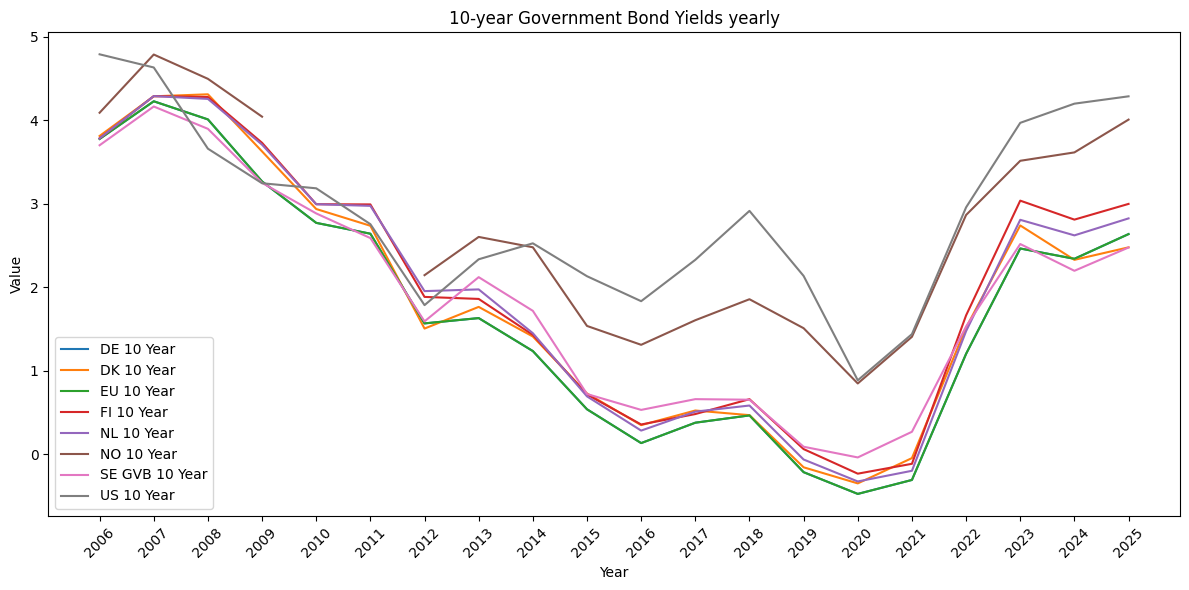

In [8]:
x = bonds_pivot["year"]

plt.figure(figsize=(12,6))
for col in bonds_pivot.columns:
    if col != "year":
        plt.plot(x, bonds_pivot[col], label=col)

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("10-year Government Bond Yields yearly")
plt.legend()

# Set x-axis to show full years only
plt.xticks(ticks=np.arange(x.min(), x.max()+1, 1), rotation=45)

plt.tight_layout()
plt.show()

In [9]:
total = bonds_pivot.merge(statista_vc_eu, how="left", on="year")

pb_vc_global = pb_vc_global.rename(columns={"value": "pb_vc_global"})
total = total.merge(pb_vc_global, how="left", on="year")

columns_to_keep = ['year', 'EU 10 Year', 'US 10 Year', 'statista_vc_eu_usd', 'pb_vc_global']
total_filtered = total[columns_to_keep]

In [10]:
# Rename columns
column_map = {
    "statista_vc_eu_usd": "VC funding EU (Statista)",
    "pb_vc_global": "VC funding global (PitchBook)",
    "EU 10 Year": "EU 10Y TBY",
    "US 10 Year": "US 10Y TBY"
}

total_filtered = total_filtered.rename(columns=column_map)
total_filtered

,year,EU 10Y TBY,US 10Y TBY,VC funding EU (Statista),VC funding global (PitchBook)
0,2006,3.77683,4.79062,NaN,NaN
1,2007,4.22784,4.63293,10.826777,NaN
2,2008,4.01097,3.66009,9.118684,50.064803
3,2009,3.26759,3.24611,5.021217,32.015472
4,2010,2.77140,3.18534,4.905152,44.844433
5,2011,2.64144,2.75567,6.402994,64.518261
6,2012,1.56703,1.78589,5.653070,56.759363
7,2013,1.63057,2.33499,6.640590,58.633845
8,2014,1.23563,2.52635,6.775354,85.592437
9,2015,0.53806,2.13219,8.432298,135.174263


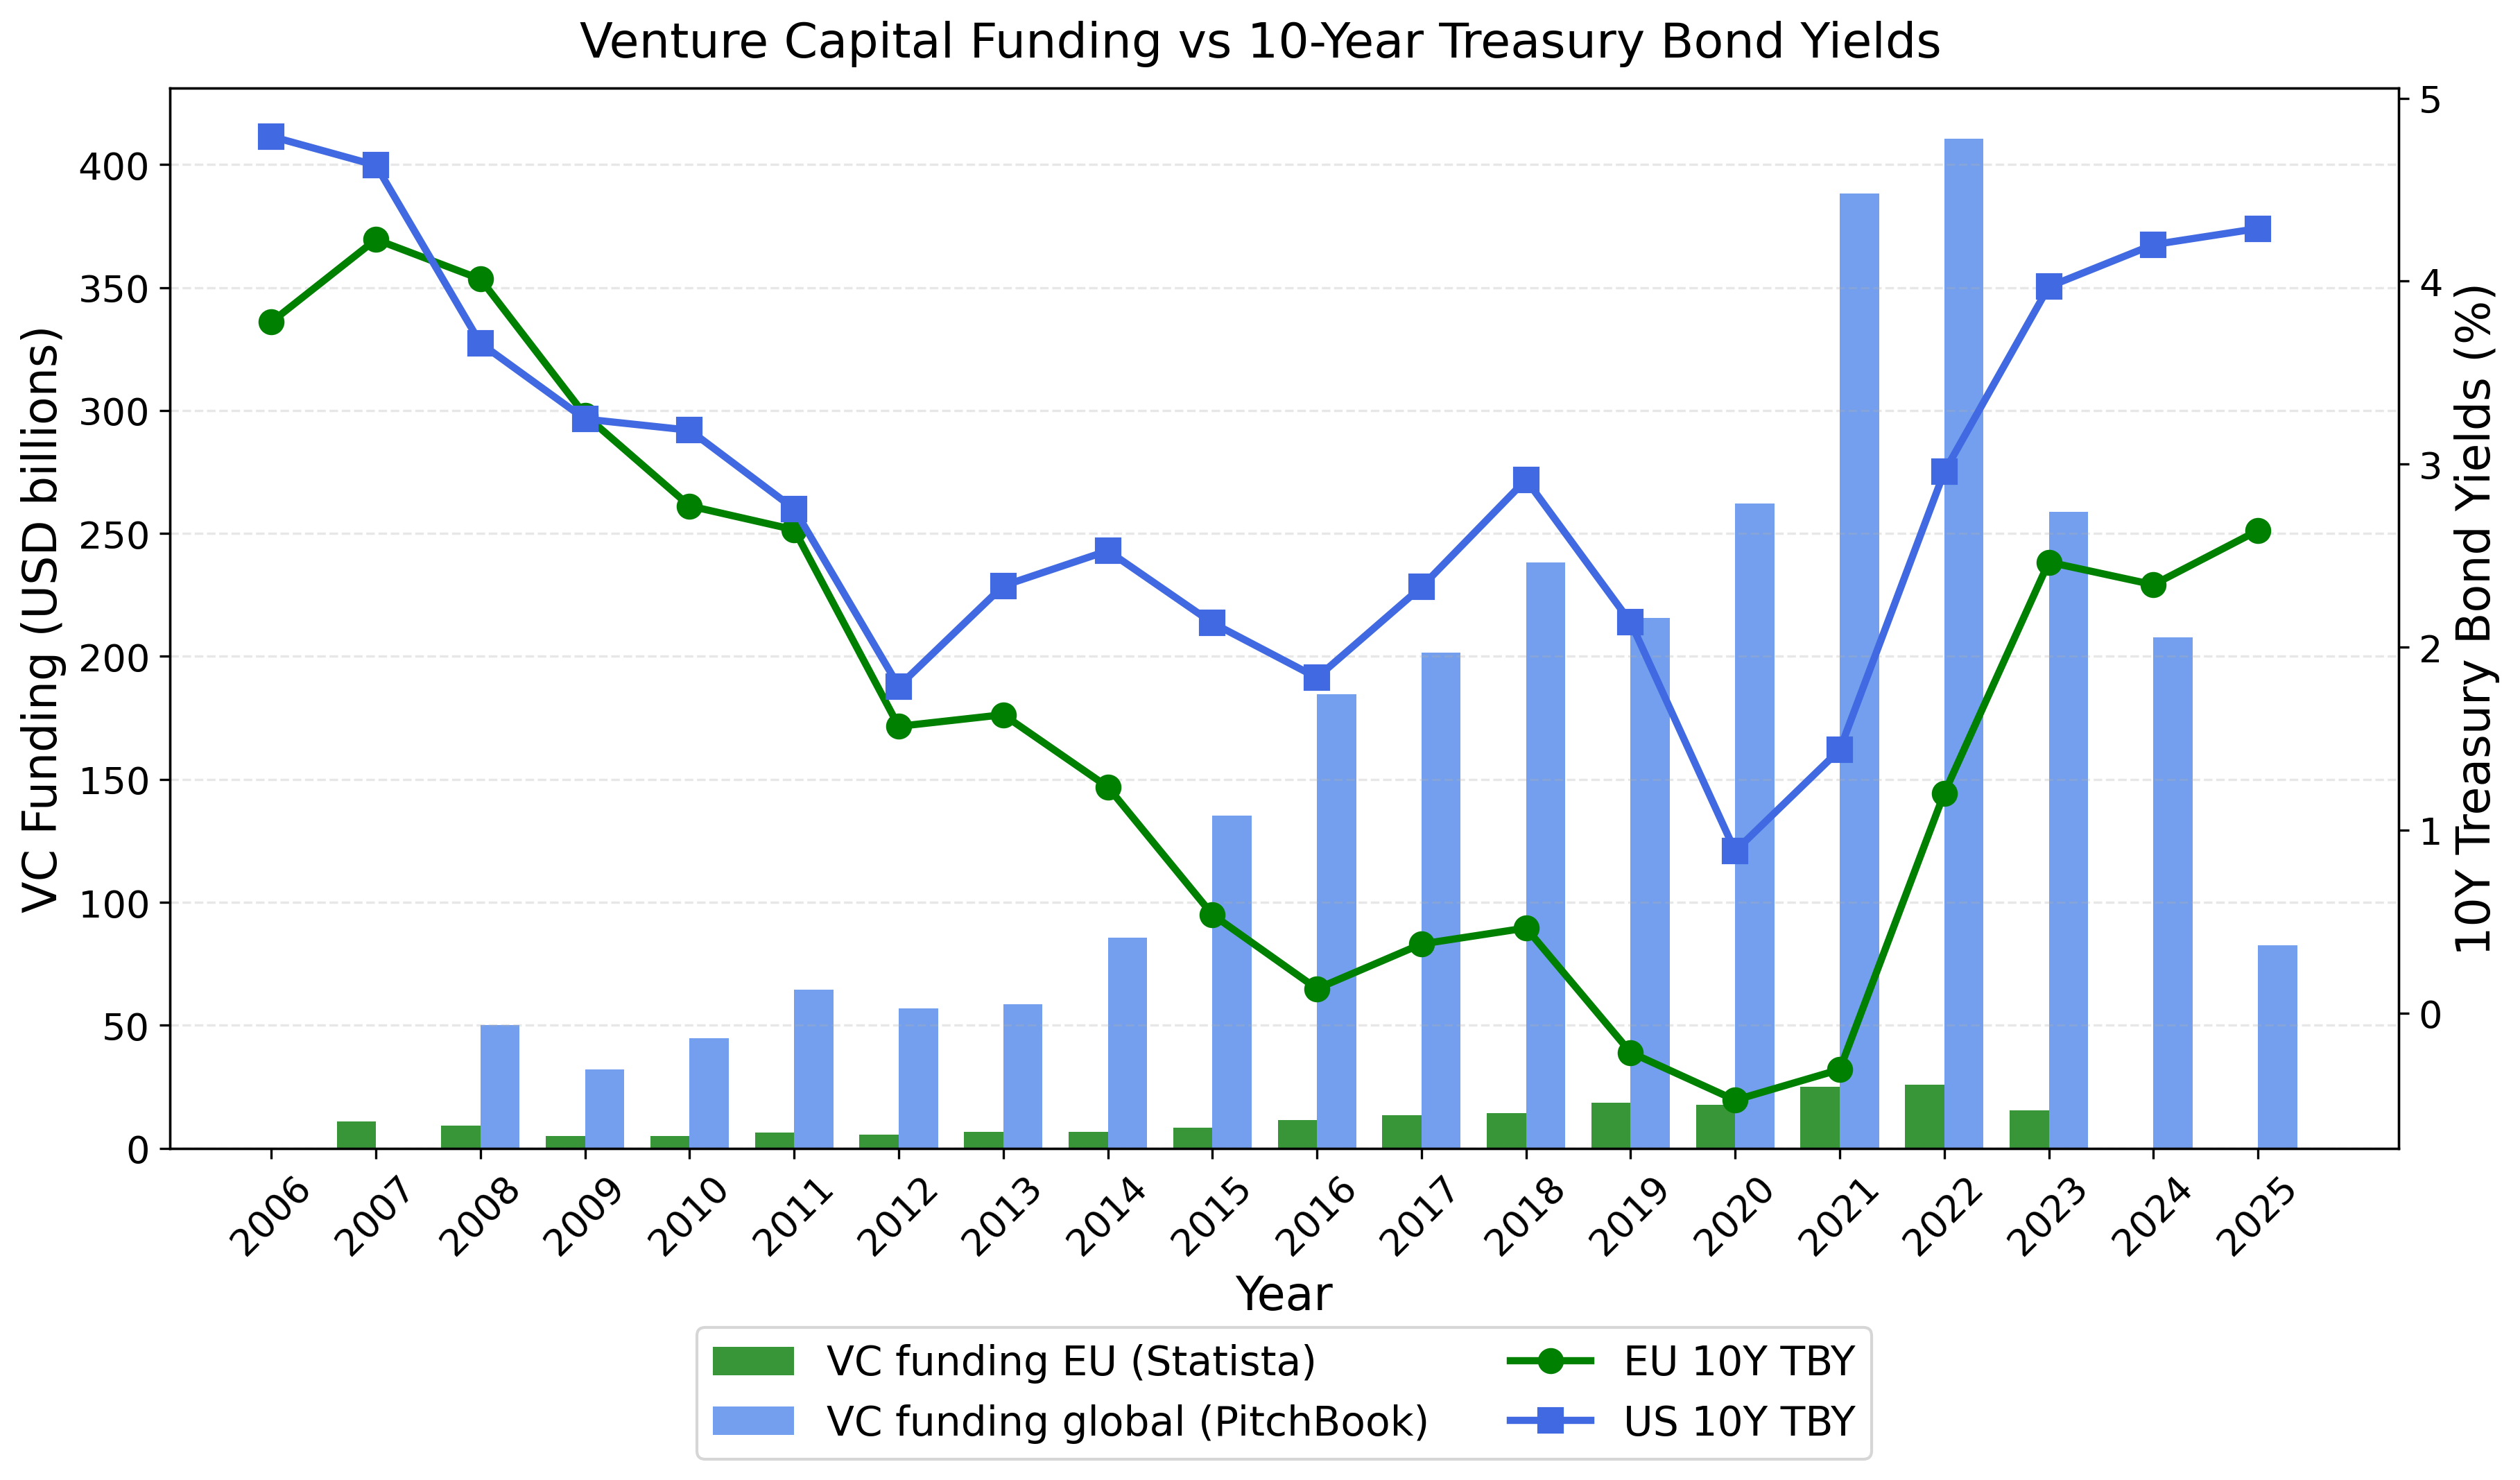

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# ---- FONT SCALING (important when figure is smaller) ----
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14
})

x = total_filtered["year"]
x_pos = np.arange(len(x))

line_cols = [col for col in total_filtered.columns if "10" in col]
bar_cols = [col for col in total_filtered.columns if col not in line_cols + ["year"]]

# ---- SMALLER FIGURE ----
fig, ax1 = plt.subplots(figsize=(12, 7), dpi=300, constrained_layout=True)

# Bars
n_bars = len(bar_cols)
bar_width = 0.75 / n_bars

bar_color_names = ["forestgreen", "cornflowerblue"]
bar_colors = [mcolors.CSS4_COLORS[name] for name in bar_color_names]

for i, col in enumerate(bar_cols):
    offset = (i - n_bars/2) * bar_width + bar_width/2
    ax1.bar(
        x_pos + offset,
        total_filtered[col],
        width=bar_width,
        color=bar_colors[i],
        alpha=0.9,
        label=col
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("VC Funding (USD billions)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=45)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

# Lines

line_color_names = ['green', 'royalblue']
line_colors = [mcolors.CSS4_COLORS[name] for name in line_color_names]

if line_cols:
    ax2 = ax1.twinx()

    markers = ['o', 's']
    for j, col in enumerate(line_cols):
        ax2.plot(
            x_pos,
            total_filtered[col],
            marker=markers[j],
            markersize=8,
            linewidth=2.5,
            color=line_colors[j],
            label=col
        )

    ax2.set_ylabel("10Y Treasury Bond Yields (%)")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels() if line_cols else ([], [])

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True
)

plt.suptitle("Venture Capital Funding vs 10-Year Treasury Bond Yields")
plt.savefig('plots/vc_vs_tby.pdf', bbox_inches='tight')
plt.show()

In [12]:
# Create total_lag as a copy of total_filtered
total_lag = total_filtered.copy()

# Create lag columns for EU 10 Year
total_lag["EU 10Y TBY Lag 1"] = total_lag["EU 10Y TBY"].shift(1)
total_lag["EU 10Y TBY Lag 2"] = total_lag["EU 10Y TBY"].shift(2)
total_lag["EU 10Y TBY Lag 3"] = total_lag["EU 10Y TBY"].shift(3)
total_lag["EU 10Y TBY Lag 4"] = total_lag["EU 10Y TBY"].shift(4)
total_lag["EU 10Y TBY Lag 5"] = total_lag["EU 10Y TBY"].shift(5)

# Create lag columns for US 10 Year
total_lag["US 10Y TBY Lag 1"] = total_lag["US 10Y TBY"].shift(1)
total_lag["US 10Y TBY Lag 2"] = total_lag["US 10Y TBY"].shift(2)
total_lag["US 10Y TBY Lag 3"] = total_lag["US 10Y TBY"].shift(3)
total_lag["US 10Y TBY Lag 4"] = total_lag["US 10Y TBY"].shift(4)
total_lag["US 10Y TBY Lag 5"] = total_lag["US 10Y TBY"].shift(5)

# Reorder columns to group them logically
column_order = [
    "year",

    # EU yield + lags
    "EU 10Y TBY",
    "EU 10Y TBY Lag 1",
    "EU 10Y TBY Lag 2",
    "EU 10Y TBY Lag 3",
    "EU 10Y TBY Lag 4",
    "EU 10Y TBY Lag 5",

    # US yield + lags
    "US 10Y TBY",
    "US 10Y TBY Lag 1",
    "US 10Y TBY Lag 2",
    "US 10Y TBY Lag 3",
    "US 10Y TBY Lag 4",
    "US 10Y TBY Lag 5",

    # VC variables
    "VC funding EU (Statista)",
    "VC funding global (PitchBook)"
]

total_lag = total_lag[column_order]

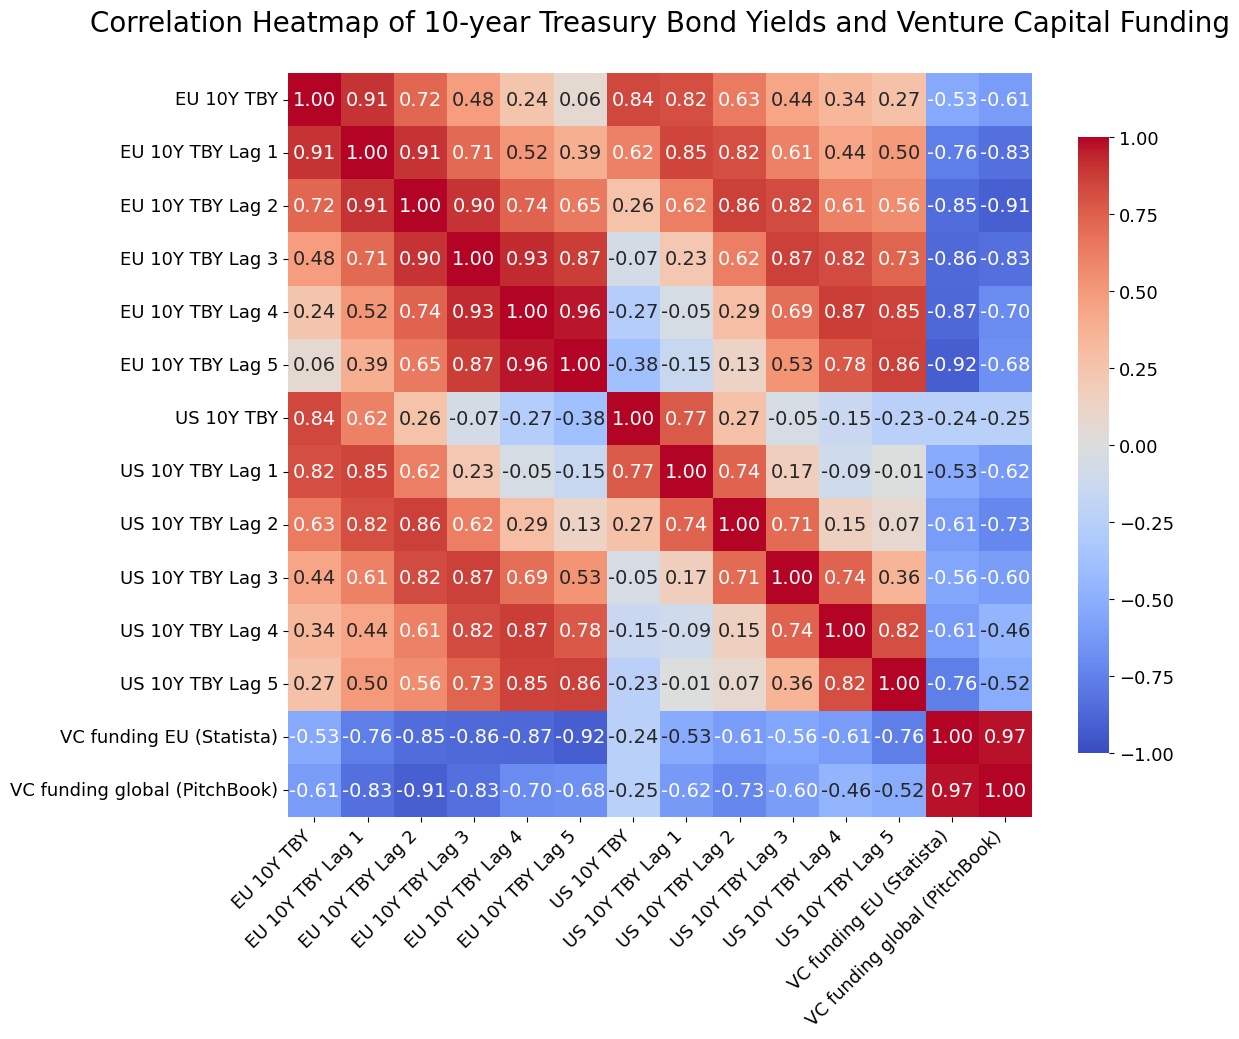

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = total_lag.drop(columns=['year']).corr()

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

# Rotate and align x-tick labels (header)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Rotate and align y-tick labels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')

# Increase space for title
ax.set_title(
    "Correlation Heatmap of 10-year Treasury Bond Yields and Venture Capital Funding",
    pad=30  # moves title away from heatmap
)

plt.savefig('plots/vc_vs_tby_corr.pdf', bbox_inches='tight')

plt.show()

In [14]:
total_lag_clean

NameError: name 'total_lag_clean' is not defined

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define dependent and independent variables
total_lag_clean = total_lag.dropna()
y = total_lag_clean["VC funding EU (Statista)"].values
X = total_lag_clean[["EU 10Y TBY Lag 1", "EU 10Y TBY Lag 2", "EU 10Y TBY Lag 3", "EU 10Y TBY Lag 4"]].values

# 2. Fit the regression
model = LinearRegression()
model.fit(X, y)

# 3. Predictions
y_pred = model.predict(X)

# 4. Performance metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = mse ** 0.5

# 5. Print results
print("Regression coefficients:")
for col, coef in zip(["EU 10 Year Lag1", "EU 10 Year Lag2", "EU 10 Year Lag3", "EU 10 Year Lag4"], model.coef_):
    print(f"{col}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

print("\nPerformance metrics:")
print(f"R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Regression coefficients:
EU 10 Year Lag1: -2.5931
EU 10 Year Lag2: -2.3250
EU 10 Year Lag3: 0.4915
EU 10 Year Lag4: -0.9425
Intercept: 19.2187

Performance metrics:
R-squared: 0.8024
MSE: 8.5797
RMSE: 2.9291
